In [62]:
#importar librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [63]:
# Matriz de transicion para las marcas de cola
# Estados: A (Coca Cola), B (Pepsi), C (Del Valle)
matriz_cola = np.array([
    [0.6, 0.3, 0.1],  #A: 60% A, 30% B, 10% C
    [0.3, 0.5, 0.2],  #B: 30% A, 50% B, 20% C
    [0.4, 0.3, 0.3]   #C: 40% A, 30% B, 30% C
])
print("Matriz de transicion:")
print(matriz_cola)

Matriz de transicion:
[[0.6 0.3 0.1]
 [0.3 0.5 0.2]
 [0.4 0.3 0.3]]


In [64]:
# Funcion para encontrar la distribucion estacionaria
n = matriz_cola.shape[0]
v = np.ones(n) / n  # Vector inicial 
print("Distribución inicial uniforme:")
print(np.round(v, 4))

for i in range(1000):
    v_anterior = v.copy()
    v = v @ matriz_cola
    
    # Mostrar cada ciertas iteraciones
    if i < 10 or (i + 1) % 10 == 0:
        print(f"Iteración {i+1}: {np.round(v, 4)}")
    
    # Verificar convergencia
    if np.allclose(v_anterior, v, atol=1e-6):
        print(f"\nConvergencia alcanzada en {i+1} iteraciones.")
        break
else:
    print("\nNo se alcanzo convergencia despues de 1000 iteraciones.")

print("\nDistribución estacionaria:")
print(np.round(v, 4))

Distribución inicial uniforme:
[0.3333 0.3333 0.3333]
Iteración 1: [0.4333 0.3667 0.2   ]
Iteración 2: [0.45   0.3733 0.1767]
Iteración 3: [0.4527 0.3747 0.1727]
Iteración 4: [0.4531 0.3749 0.172 ]
Iteración 5: [0.4531 0.375  0.1719]
Iteración 6: [0.4531 0.375  0.1719]
Iteración 7: [0.4531 0.375  0.1719]

Convergencia alcanzada en 7 iteraciones.

Distribución estacionaria:
[0.4531 0.375  0.1719]


In [65]:
# A. Cantidades de población en estado estacionario para 1000 elementos
poblacion_total = 1000
distribucion_inicial = np.array([200, 300, 500]) / poblacion_total 

n = matriz_cola.shape[0]
v = distribucion_inicial.copy()
print("Distribucion inicial [A=200, B=300, C=500]:")
print(np.round(v, 4))

for i in range(1000):
    v_anterior = v.copy()
    v = v @ matriz_cola
    
    if np.allclose(v_anterior, v, atol=1e-6):
        print(f"Convergencia alcanzada en {i + 1} iteraciones.")
        break

cantidades = v * poblacion_total
print("\nA. Cantidades en estado estacionario (1000 personas):")
print(f"Marca A: {np.round(cantidades[0], 1)}")
print(f"Marca B: {np.round(cantidades[1], 1)}")
print(f"Marca C: {np.round(cantidades[2], 1)}")

Distribucion inicial [A=200, B=300, C=500]:
[0.2 0.3 0.5]
Convergencia alcanzada en 8 iteraciones.

A. Cantidades en estado estacionario (1000 personas):
Marca A: 453.1
Marca B: 375.0
Marca C: 171.9



B. Consumo anual total: 2,600,000,000 litros
Consumo anual por marca:
Marca A: 1,178,125,312.0 litros
Marca B: 974,999,501.0 litros
Marca C: 446,875,187.0 litros


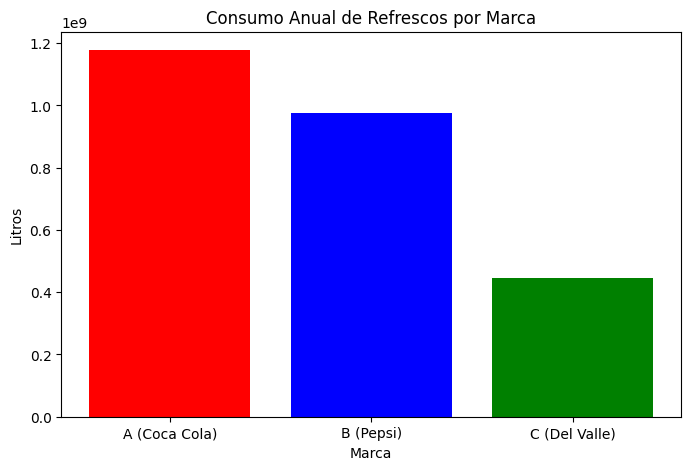

In [66]:
# B. Consumo anual
habitantes = 50_000_000  # 50 millones
consumo_semanal_por_persona = 1  # litro
semanas_por_anio = 52
consumo_anual_total = habitantes * consumo_semanal_por_persona * semanas_por_anio
print(f"\nB. Consumo anual total: {consumo_anual_total:,} litros")

consumo_por_marca = v * consumo_anual_total
print("Consumo anual por marca:")
print(f"Marca A: {np.round(consumo_por_marca[0], 0):,} litros")
print(f"Marca B: {np.round(consumo_por_marca[1], 0):,} litros")
print(f"Marca C: {np.round(consumo_por_marca[2], 0):,} litros")

# Grafico
marcas = ['A (Coca Cola)', 'B (Pepsi)', 'C (Del Valle)']
plt.figure(figsize=(8, 5))
plt.bar(marcas, consumo_por_marca, color=['red', 'blue', 'green'])
plt.title('Consumo Anual de Refrescos por Marca')
plt.ylabel('Litros')
plt.xlabel('Marca')
plt.show()

In [67]:
# C. Campana publicitaria para marca C
retencion_original_c = 0.3
retencion_nueva_c = 0.4
factor_ajuste = (1 - retencion_nueva_c) / (1 - retencion_original_c)
print(f"\nC. Factor de ajuste para salidas de C: {factor_ajuste:.4f}")

# Nueva fila para C
nueva_fila_c = np.array([0.4 * factor_ajuste, 0.3 * factor_ajuste, retencion_nueva_c])
print(f"Nueva fila para C: {np.round(nueva_fila_c, 4)}")

# Nueva matriz con campana
matriz_campania = matriz_cola.copy()
matriz_campania[2] = nueva_fila_c  # fila c
print("Matriz con campana:")
print(np.round(matriz_campania, 4))

# Calcular distribución estacionaria
n = matriz_campania.shape[0]
v = np.ones(n) / n  # Vector inicial 

print("\nCalculando distribucion estacionaria: ")

for i in range(1000):
    v_anterior = v.copy()
    v = v @ matriz_campania
    
    if np.allclose(v_anterior, v, atol=1e-6):
        print(f"Convergencia alcanzada en {i + 1} iteraciones.")
        break
else:
    print("No se alcanzo convergencia despues de 1000 iteraciones.")

stationary_campania = v
print("\nDistribución estacionaria con campana:")
print(np.round(stationary_campania, 4))


C. Factor de ajuste para salidas de C: 0.8571
Nueva fila para C: [0.3429 0.2571 0.4   ]
Matriz con campana:
[[0.6    0.3    0.1   ]
 [0.3    0.5    0.2   ]
 [0.3429 0.2571 0.4   ]]

Calculando distribucion estacionaria: 
Convergencia alcanzada en 9 iteraciones.

Distribución estacionaria con campana:
[0.4405 0.3646 0.1949]


In [68]:
# Utilidad por litro: 0.25 centavos de dolar = 0.0025 USD
utilidad_por_litro = 0.0025

# Utilidad sin campana
utilidad_sin_campania = consumo_por_marca[2] * utilidad_por_litro
print(f"\nUtilidad anual sin campana para C: ${utilidad_sin_campania:,.2f} USD")

# Utilidad con campana
consumo_c_campania = stationary_campania[2] * consumo_anual_total
utilidad_con_campania = consumo_c_campania * utilidad_por_litro
print(f"Utilidad anual con campana para C: ${utilidad_con_campania:,.2f} USD")

# Incremento en utilidad
incremento_utilidad = utilidad_con_campania - utilidad_sin_campania
print(f"Incremento en utilidad: ${incremento_utilidad:,.2f} USD")

# Inversion
inversion = 20_000_000
print(f"Inversión requerida: ${inversion:,.0f} USD")

# ¿Vale la pena?
if incremento_utilidad > inversion:
    print("Sí vale la pena implementar la campana.")
else:
    print("No vale la pena implementar la campana.")


Utilidad anual sin campana para C: $1,117,187.97 USD
Utilidad anual con campana para C: $1,267,091.38 USD
Incremento en utilidad: $149,903.41 USD
Inversión requerida: $20,000,000 USD
No vale la pena implementar la campana.
